# Template fNIRS pipeline

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#requires ipympl package
%matplotlib ipympl

In [2]:
# import pyphysio
from pyphysio import TestData
from pyphysio import create_signal

nirs = TestData.fnirs(return_signal=True)
tapping = TestData.tapping(return_signal=True)

Using dask. Scheduler: threads
Please cite:
Bizzego et al. (2019) 'pyphysio: A physiological signal processing library for data science approaches in physiology', SoftwareX


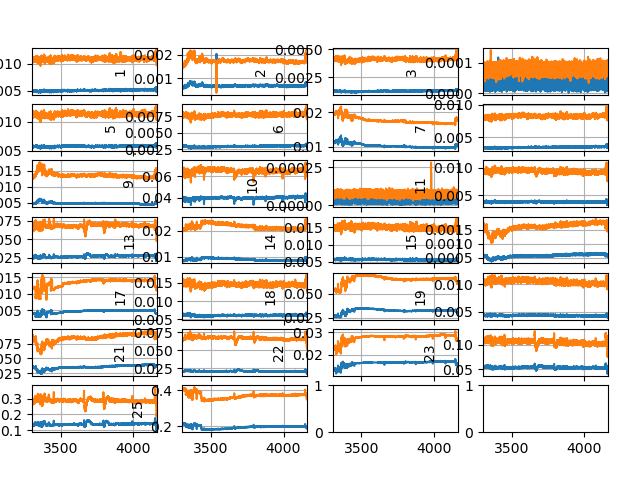

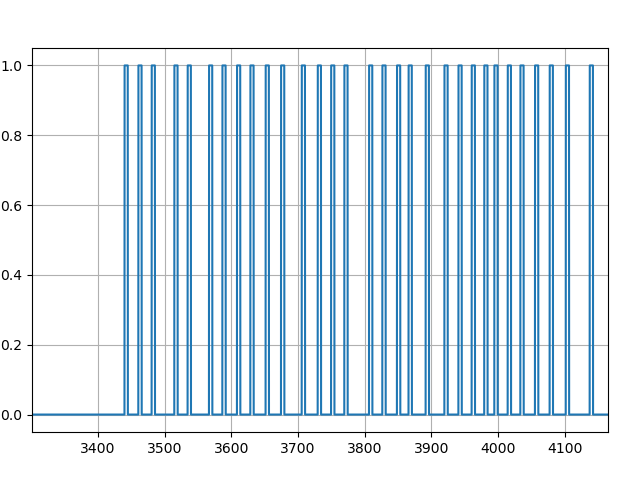

In [3]:
plt.figure()
nirs.p.plot()

plt.figure()
tapping.p.plot()

[3, 6, 10, 13, 16, 18, 22, 25] [0, 1, 2, 4, 5, 7, 8, 9, 11, 12, 14, 15, 17, 19, 20, 21, 23, 24]
[1 3 0]


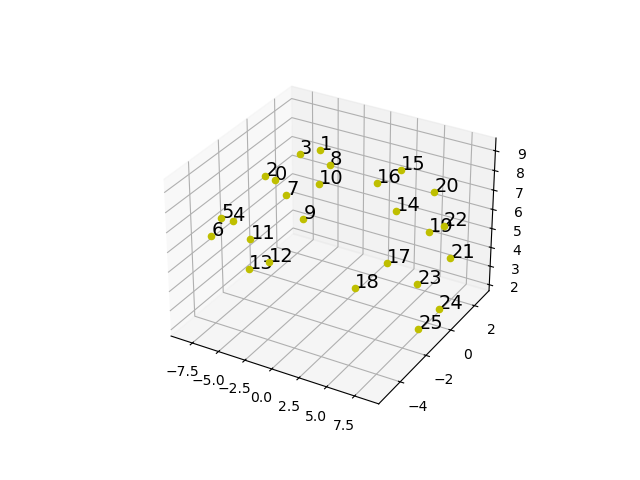

In [4]:
from pyphysio.specialized.fnirs import plot_probe, get_ss_ls_channels, get_near_channels



id_ss, id_ls = get_ss_ls_channels(nirs)
print(id_ss, id_ls)
near_1 = get_near_channels(nirs, ch_target=1)
print(near_1)

plot_probe(nirs)

## Signal Quality

In [5]:
from pyphysio.specialized.fnirs._dl_sqi import SignalQualityDeepLearning
from pyphysio.segmenters import FixedSegments, fmap

In [6]:
# SQI using Deep Learning
segmenter = FixedSegments(10, 20)
indicators = [SignalQualityDeepLearning()]

sqi = fmap(segmenter, indicators, nirs) #will take a while

In [7]:
#manipulating variables and dimensions to extract information of interest
sqi = sqi['signal_SignalQualityDeepLearning'].sel({'is_good':1, 'component':0})
sqi = sqi.drop_vars(['label'])

/mnt/raidpool/UniTn/software/pyphysio/pyphysio/signal.py:578: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string ".-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(t_, v_current, marker, linestyle = linestyle, color=color)


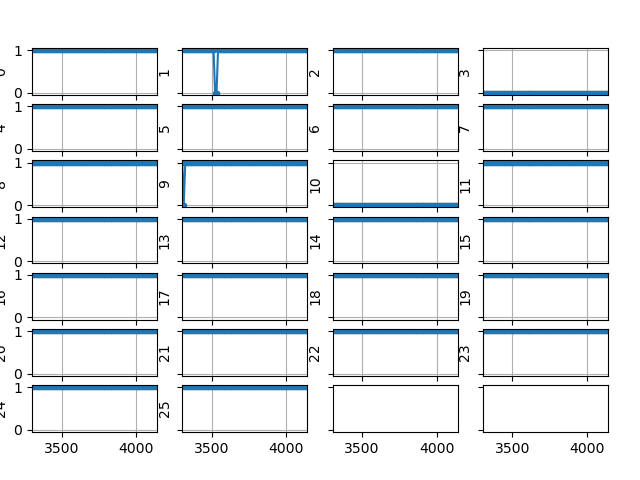

In [8]:
plt.figure()
sqi.p.plot('.-', sharey=True)

In [9]:
ratio_min_good = 0.8 #at least 80% of the windows should have a good value
isgood_ratios = np.sum(sqi.values, axis=0)/sqi.values.shape[0]
id_good_channels = np.where(isgood_ratios >= ratio_min_good)[0]
nirs.attrs['good_channels'] = id_good_channels
nirs = nirs.sel({'channel': id_good_channels})

print("good channels: ", id_good_channels)

good channels:  [ 0  1  2  4  5  6  7  8  9 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]


In [10]:
from pyphysio.specialized.fnirs import plot_probe, get_ss_ls_channels, get_near_channels, Raw2OD

nirs = Raw2OD()(nirs)

## Remove MA

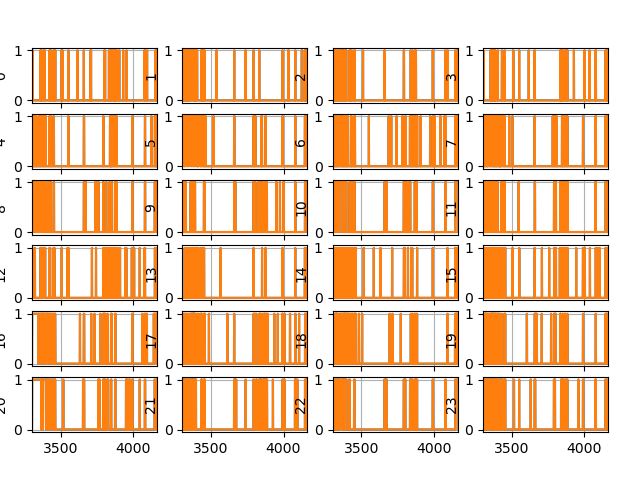

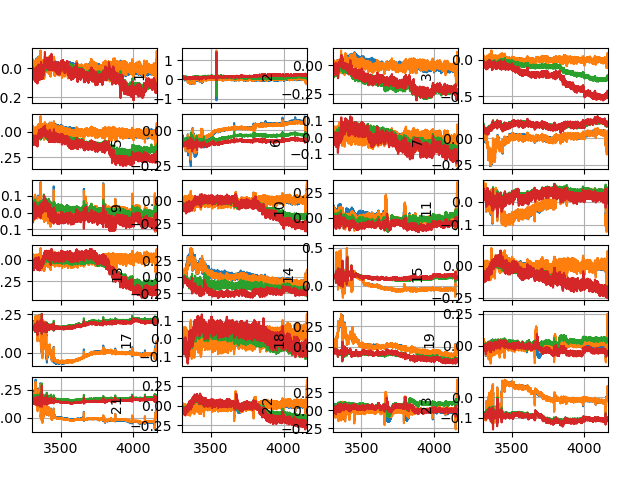

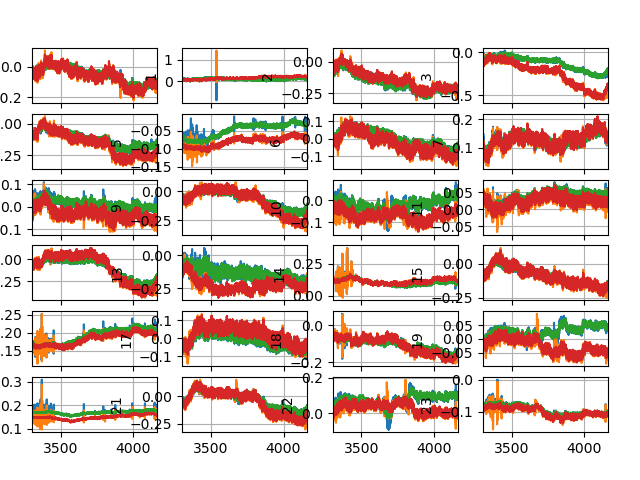

In [11]:
import pyphysio.artefacts as artefacts

MA = artefacts.DetectMA(fuse='component')(nirs)
plt.figure()
MA.p.plot()

nirs['MA'] = MA #add MA info to nirs

nirs_noMA = artefacts.MARA()(nirs)
nirs_noMA = nirs_noMA.drop_vars('MA')

plt.figure()
nirs.p.plot(sharey=False)
nirs_noMA.p.plot(sharey=False)

#remove MA with wavelet
nirs_wav = artefacts.WaveletFilter()(nirs_noMA)

plt.figure()
nirs_noMA.p.plot(sharey=False)
nirs_wav.p.plot(sharey=False)

## Convert to Oxy/DeoxyHb

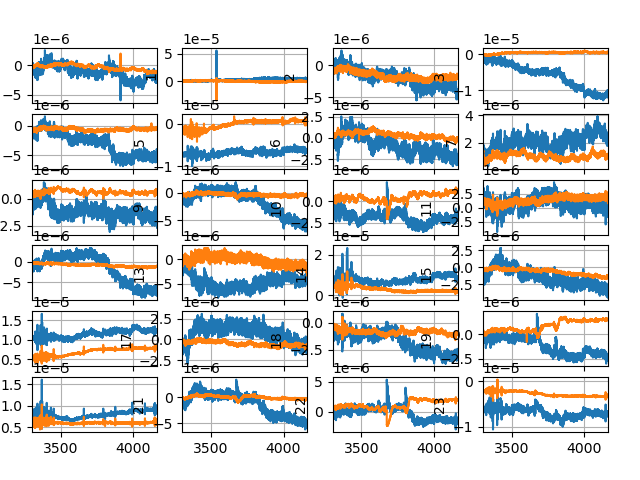

In [12]:
from pyphysio.specialized.fnirs import OD2Oxy

hb = OD2Oxy()(nirs_noMA)

plt.figure()
hb.p.plot(sharey=False)

## Remove physio noise

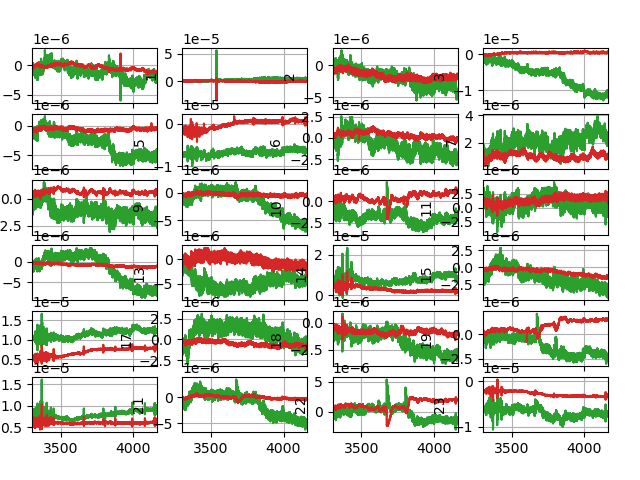

In [13]:
#%% remove physio noise
from pyphysio.specialized.fnirs import PCAFilter

pcafilt = PCAFilter()
hb_nophysio = pcafilt(hb)

plt.figure()
hb.p.plot(sharey=False)
hb_nophysio.p.plot(sharey=False)

## Compute clusters

In [14]:
from pyphysio.specialized.fnirs import ComputeClusters

cluster_compute = ComputeClusters(clusters=[[0,1,2], [4,5,6], [7,8,9]])
clusters = cluster_compute(hb_nophysio)

## Other filters?

In [15]:
import pyphysio.filters as filters

clusters_f = filters.IIRFilter(fp = [0.01, 0.2], btype='bandpass')(clusters)

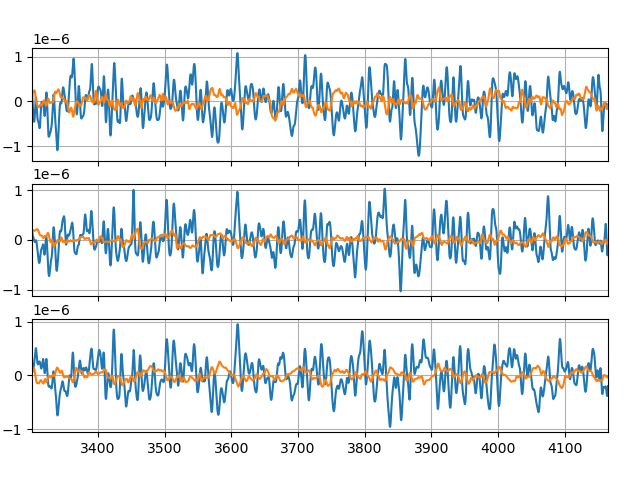

In [16]:
plt.figure()
clusters_f.p.plot(ncols=1)

## First-level GLM analysis

In [17]:
# convert tapping signal to event matrix
tapping_values = tapping.values
idx_onset = np.where(np.diff(tapping_values)>0)[0] - 1
t_onset = tapping.p.get_times()[idx_onset]

tapping.p.plot()
plt.vlines(t_onset, 0, 1, 'r')

events = pd.DataFrame({'onset': t_onset})
events['duration'] = 5
events['stim_type'] = 1

In [18]:
display(events)

,onset,duration,stim_type
0,3439.673353,5,1
1,3460.416131,5,1
2,3480.372453,5,1
3,3514.386677,5,1
4,3534.342999,5,1
5,3566.391083,5,1
6,3586.445712,5,1
7,3608.368174,5,1
8,3628.422803,5,1
9,3651.328335,5,1


### one-subject / one-channel analysis

In [19]:
sub = 'S001'

/mnt/miniconda3/mambaforge/envs/physio/lib/python3.10/site-packages/nilearn/glm/first_level/experimental_paradigm.py:131: UserWarning: 'trial_type' column not found in the given events data.
  warnings.warn(
/mnt/miniconda3/mambaforge/envs/physio/lib/python3.10/site-packages/nilearn/glm/first_level/experimental_paradigm.py:177: UserWarning: The following unexpected columns in events data will be ignored: stim_type
  warnings.warn(


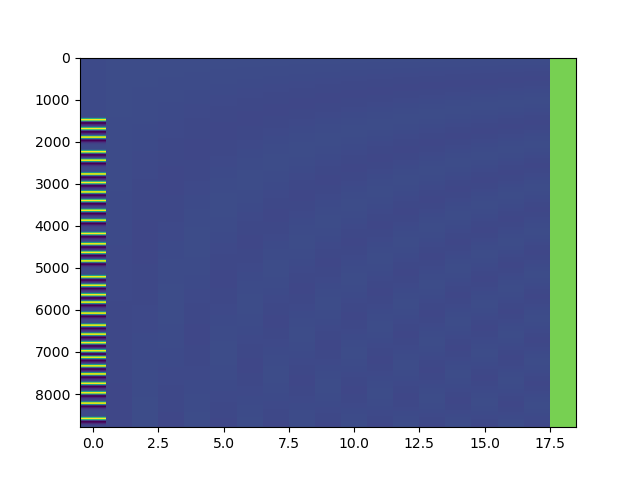

In [20]:
# create design matrix
from nilearn.glm.first_level import make_first_level_design_matrix

t = clusters_f.p.get_times()

dm = make_first_level_design_matrix(t, events)

plt.figure()
plt.imshow(dm.values, aspect='auto', interpolation='nearest')

In [21]:
# run GLM
from nilearn.glm.first_level import run_glm

X = dm.values

i_ch = 0
Y = np.expand_dims(clusters_f.p.get_values()[:, i_ch, 0], 1)

assert ~np.isnan(Y).any()

labels, glm_estimates = run_glm(Y, X)
thetas = glm_estimates[labels[0]].theta[:,0]
print(thetas)

[-1.29731918e-07  1.05043399e-07 -5.95994611e-08  3.40890475e-07
 -7.29809685e-08  4.84923453e-07  1.01169557e-07  2.25441257e-07
 -1.16051839e-07 -3.28427253e-08  3.71117309e-07 -2.63112950e-06
 -1.89428293e-06 -4.94267742e-07 -1.59850998e-06  3.48659193e-07
  5.88485932e-06  7.28836957e-06  2.69366877e-08]


### one-subject / all channels

In [22]:
betas = []

for i_ch in range(clusters_f.sizes['channel']):
    
        Y = np.expand_dims(clusters_f.p.get_values()[:, i_ch, 0], 1)

        assert ~np.isnan(Y).any()

        labels, glm_estimates = run_glm(Y, X)
        thetas = glm_estimates[labels[0]].theta[:,0]
        
        betas.append({'subject': sub,
                      'channel': i_ch,
                      'beta': thetas[0]})
            
betas = pd.DataFrame(betas)
print(betas)

  subject  channel          beta
0    S001        0 -1.297319e-07
1    S001        1 -1.282567e-07
2    S001        2 -1.321212e-07


### all subjects / all channels

In [23]:
#get list of subjects

#for each subject:
#  - process nirs signal
#  - for each channel:
#      - run first-level GLM